In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

print("数据维度：", X.shape)
print("标签类别：", data.target_names)

数据维度： (569, 30)
标签类别： ['malignant' 'benign']


In [4]:
rfc = RandomForestClassifier(n_estimators=100, random_state=90)
score_pre = cross_val_score(rfc, X, y, cv=10).mean()
print("原始模型准确率 acc =", round(score_pre, 4))

原始模型准确率 acc = 0.9649


In [5]:
scorel = []
for i in range(1, 201, 10):
    clf = RandomForestClassifier(n_estimators=i, n_jobs=-1, random_state=90)
    score = cross_val_score(clf, X, y, cv=10).mean()
    scorel.append(score)

/Users/maokeyu/Desktop/Work/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20083 (\N{CJK UNIFIED IDEOGRAPH-4E73}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/Work/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 33146 (\N{CJK UNIFIED IDEOGRAPH-817A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/Work/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30284 (\N{CJK UNIFIED IDEOGRAPH-764C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/Work/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/maokeyu/Desktop/Work/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py

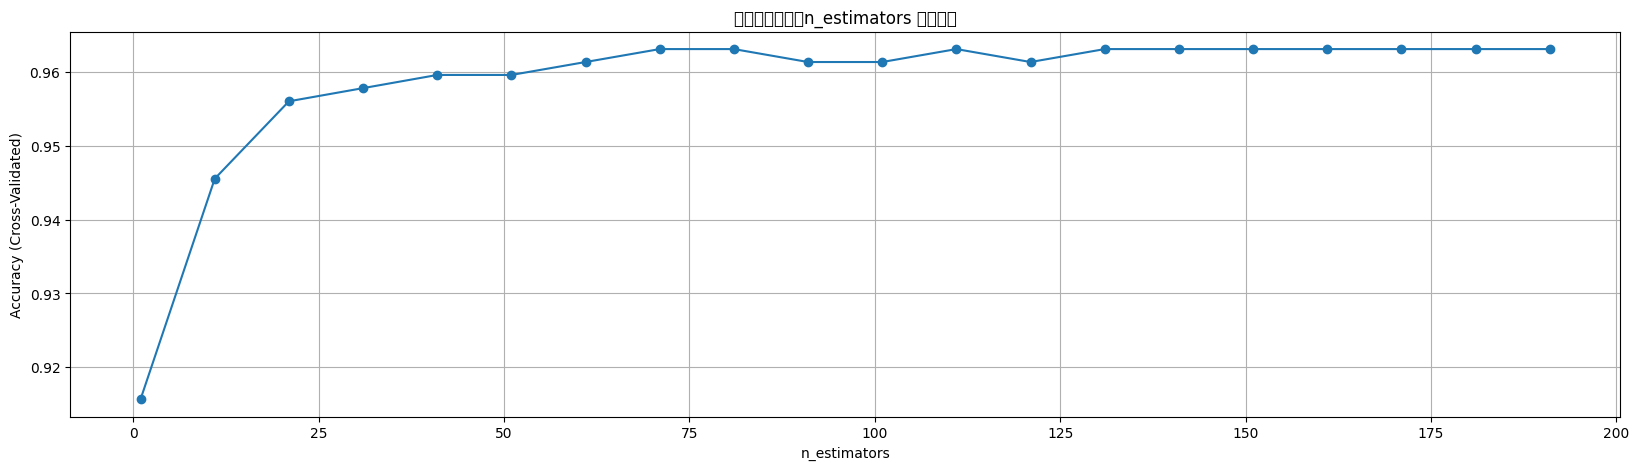

In [6]:
plt.figure(figsize=[20, 5])
plt.plot(range(1, 201, 10), scorel, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Accuracy (Cross-Validated)")
plt.title("乳腺癌数据集：n_estimators 学习曲线")
plt.grid(True)
plt.show()

In [7]:
best_score = max(scorel)
best_index = scorel.index(best_score)
best_n = (best_index * 10) + 1
print(f"最大准确率：{best_score:.4f}，对应的 n_estimators 为：{best_n}")

最大准确率：0.9631，对应的 n_estimators 为：71
